# matplotlib 日本語フォントインストール

In [1]:
# 日本語フォントをインストールする（1回だけ実行すればOK）
import subprocess
subprocess.run(["apt-get", "install", "-y", "fonts-ipaexfont"],
               capture_output=True)

# フォントキャッシュをリセット
import matplotlib
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

print("✅ フォントインストール完了")

✅ フォントインストール完了


# 読込、型確認

In [2]:
# ============================================================
# 【初期化】毎回ここから実行する
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import requests
import os
import time
import unicodedata
from datetime import datetime

# ============================================================
# 【1】Excelファイルを読み込む
# ============================================================
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/勤怠データ_2024年10月.xlsx")
print(f"✅ 読み込み完了：{len(df)}行・{len(df.columns)}列")

# ============================================================
# 【2】データ診断レポート
# ============================================================
print("\n" + "=" * 40)
print("データ診断レポート")
print("=" * 40)

for col in df.columns:
    print(f"\n【{col}】")

    if df[col].dtype == "object":
        if df[col].str.contains("\u3000", na=False).any():
            print("  ⚠️ 全角スペースあり")
        if df[col].str.contains(r"^\s|\s$", na=False).any():
            print("  ⚠️ 前後にスペースあり")
        if df[col].str.contains(r"[０-９]", na=False).any():
            print("  ⚠️ 全角数字あり")
        if (df[col].str.upper() != df[col]).any():
            print("  ⚠️ 大文字小文字の混在あり")

    null_count = df[col].isnull().sum()
    if null_count > 0:
        print(f"  ⚠️ 空欄：{null_count}件")

    if df[col].dtype != "object" and null_count == 0:
        print(f"  ✅ 問題なし（型：{df[col].dtype}）")

# 重複行の確認
print(f"\n【重複行】")
duplicates = df[df.duplicated(subset="社員ID", keep=False)]
if len(duplicates) > 0:
    print(f"  ⚠️ 重複あり：{len(duplicates)}件")
    for sid in duplicates["社員ID"].unique():
        rows = duplicates[duplicates["社員ID"] == sid]
        print(f"    社員ID「{sid}」が{len(rows)}行あります")
else:
    print("  ✅ 重複なし")

print("\n" + "=" * 40)
print("診断完了")
print("=" * 40)

# ============================================================
# 【3】診断 & 自動修正
# ============================================================
df3 = df.copy()

print("\n" + "=" * 40)
print("診断 & 自動修正レポート")
print("=" * 40)

for col in df3.columns:
    print(f"\n【{col}】")
    fixed = False

    if df3[col].dtype == "object":
        if df3[col].str.contains("\u3000", na=False).any():
            df3[col] = df3[col].str.replace("\u3000", " ")
            print("  ✅ 全角スペース→半角スペースに修正")
            fixed = True
        if df3[col].str.contains(r"^\s|\s$", na=False).any():
            df3[col] = df3[col].str.strip()
            print("  ✅ 前後のスペースを除去")
            fixed = True
        if df3[col].str.contains(r"[０-９]", na=False).any():
            df3[col] = df3[col].apply(
                lambda x: unicodedata.normalize("NFKC", str(x))
                if pd.notna(x) else x
            )
            print("  ✅ 全角数字→半角数字に修正")
            fixed = True
        if (df3[col].str.upper() != df3[col]).any():
            df3[col] = df3[col].str.upper()
            print("  ✅ 大文字に統一")
            fixed = True

    if col == "出勤日数":
        df3[col] = pd.to_numeric(df3[col], errors="coerce")
        df3[col] = df3[col].fillna(0).astype(int)
        print("  ✅ 数値型（整数）に変換")
        fixed = True

    null_count = df3[col].isnull().sum()
    if null_count > 0:
        print(f"  ⚠️ 空欄{null_count}件（要確認・自動修正せず）")
        fixed = True

    if not fixed:
        print("  ✅ 問題なし")

print("\n" + "=" * 40)
print("修正完了")
print("=" * 40)

# ============================================================
# 【4】給与計算
# ============================================================
df3["月給"]   = df3["出勤日数"] * df3["時給"] * 8
df3["残業代"] = df3["残業時間"] * df3["時給"] * 1.25
df3["支給合計"] = df3["月給"] + df3["残業代"]

print(f"\n✅ 給与計算完了")
print(f"支給合計：{df3['支給合計'].sum():,.0f}円")
print(f"一人平均：{df3['支給合計'].mean():,.0f}円")

# ============================================================
# 【5】クリーニング済みExcelを書き出す
# ============================================================
now = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"/content/drive/MyDrive/Colab Notebooks/勤怠データ_2024年10月_クリーニング済_{now}.xlsx"

df3.to_excel(output_path, index=False, sheet_name="2024年10月")
print(f"\n✅ Excel書き出し完了")
print(f"ファイル名：勤怠データ_2024年10月_クリーニング済_{now}.xlsx")
print(f"出力行数：{len(df3)}行")

# ============================================================
# 【6】郵便番号APIで住所を自動補完
# ============================================================
employees = [
    {"氏名": "田中 太郎", "郵便番号": "3500043"},
    {"氏名": "鈴木 花子", "郵便番号": "3300063"},
    {"氏名": "佐藤 次郎", "郵便番号": "1000001"},
    {"氏名": "山田 美咲", "郵便番号": "4600008"},
    {"氏名": "伊藤 健一", "郵便番号": "9999999"},
]

results = []
for emp in employees:
    url = f"https://zipcloud.ibsnet.co.jp/api/search?zipcode={emp['郵便番号']}"
    response = requests.get(url)
    data = response.json()

    if data["results"]:
        r = data["results"][0]
        results.append({
            "氏名":     emp["氏名"],
            "郵便番号": emp["郵便番号"],
            "住所":     f"{r['address1']}{r['address2']}{r['address3']}",
            "ふりがな": f"{r['kana1']}{r['kana2']}{r['kana3']}",
            "状態":     "✅ 取得成功"
        })
    else:
        results.append({
            "氏名":     emp["氏名"],
            "郵便番号": emp["郵便番号"],
            "住所":     "",
            "ふりがな": "",
            "状態":     "⚠️ 見つかりません"
        })
    time.sleep(0.5)

df_address = pd.DataFrame(results)

now2 = datetime.now().strftime("%Y%m%d_%H%M%S")
address_path = f"/content/drive/MyDrive/Colab Notebooks/従業員住所録_{now2}.xlsx"
df_address.to_excel(address_path, index=False, sheet_name="住所録")

print(f"\n✅ 住所録Excel書き出し完了")
print(f"ファイル名：従業員住所録_{now2}.xlsx")
df_address

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 読み込み完了：12行・7列

データ診断レポート

【社員ID】
  ⚠️ 大文字小文字の混在あり

【氏名】
  ⚠️ 全角スペースあり

【部署】

【出勤日数】
  ⚠️ 全角数字あり
  ⚠️ 大文字小文字の混在あり
  ⚠️ 空欄：1件

【残業時間】
  ✅ 問題なし（型：int64）

【時給】
  ✅ 問題なし（型：int64）

【備考】
  ⚠️ 大文字小文字の混在あり
  ⚠️ 空欄：9件

【重複行】
  ⚠️ 重複あり：2件
    社員ID「E001」が2行あります

診断完了

診断 & 自動修正レポート

【社員ID】
  ✅ 大文字に統一

【氏名】
  ✅ 全角スペース→半角スペースに修正

【部署】
  ✅ 問題なし

【出勤日数】
  ✅ 全角数字→半角数字に修正
  ✅ 大文字に統一
  ✅ 数値型（整数）に変換

【残業時間】
  ✅ 問題なし

【時給】
  ✅ 問題なし

【備考】
  ✅ 大文字に統一
  ⚠️ 空欄9件（要確認・自動修正せず）

修正完了

✅ 給与計算完了
支給合計：3,998,225円
一人平均：333,185円

✅ Excel書き出し完了
ファイル名：勤怠データ_2024年10月_クリーニング済_20260406_040821.xlsx
出力行数：12行

✅ 住所録Excel書き出し完了
ファイル名：従業員住所録_20260406_040824.xlsx


,氏名,郵便番号,住所,ふりがな,状態
0,田中 太郎,3500043,埼玉県川越市新富町,ｻｲﾀﾏｹﾝｶﾜｺﾞｴｼｼﾝﾄﾐﾁｮｳ,✅ 取得成功
1,鈴木 花子,3300063,埼玉県さいたま市浦和区高砂,ｻｲﾀﾏｹﾝｻｲﾀﾏｼｳﾗﾜｸﾀｶｻｺﾞ,✅ 取得成功
2,佐藤 次郎,1000001,東京都千代田区千代田,ﾄｳｷｮｳﾄﾁﾖﾀﾞｸﾁﾖﾀﾞ,✅ 取得成功
3,山田 美咲,4600008,愛知県名古屋市中区栄,ｱｲﾁｹﾝﾅｺﾞﾔｼﾅｶｸｻｶｴ,✅ 取得成功
4,伊藤 健一,9999999,,,⚠️ 見つかりません


# matplotlib（棒グラフ）

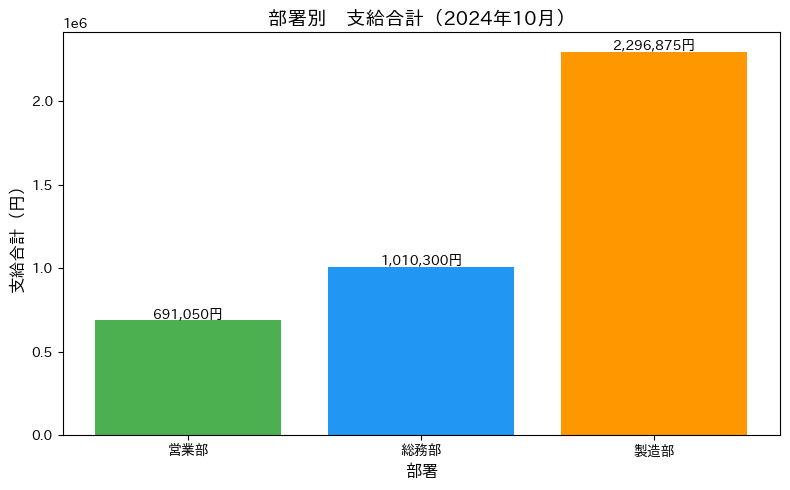

In [3]:
import matplotlib.pyplot as plt
import matplotlib

# 日本語フォントの設定（これがないと日本語が文字化けする）
matplotlib.rc('font', family='IPAexGothic')

# 部署別の支給合計を集計
df_dept = df3.groupby("部署")["支給合計"].sum().reset_index()

# 棒グラフを作成
plt.figure(figsize=(8, 5))
plt.bar(df_dept["部署"], df_dept["支給合計"],
        color=["#4CAF50", "#2196F3", "#FF9800"])

plt.title("部署別　支給合計（2024年10月）", fontsize=14)
plt.xlabel("部署", fontsize=12)
plt.ylabel("支給合計（円）", fontsize=12)

for i, row in df_dept.iterrows():
    plt.text(i, row["支給合計"] + 5000, f"{row['支給合計']:,.0f}円",
             ha="center", fontsize=10)

plt.tight_layout()
plt.show()

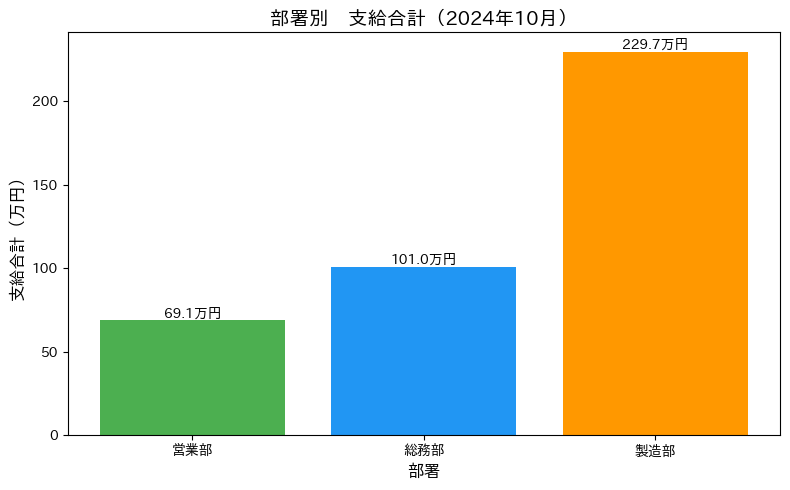

In [4]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='IPAexGothic')

# 部署別の支給合計を集計（万円単位に変換）
df_dept = df3.groupby("部署")["支給合計"].sum().reset_index()
df_dept["支給合計_万円"] = df_dept["支給合計"] / 10000

# 棒グラフを作成
plt.figure(figsize=(8, 5))
plt.bar(df_dept["部署"], df_dept["支給合計_万円"],
        color=["#4CAF50", "#2196F3", "#FF9800"])

plt.title("部署別　支給合計（2024年10月）", fontsize=14)
plt.xlabel("部署", fontsize=12)
plt.ylabel("支給合計（万円）", fontsize=12)

# 棒の上に数字を表示（万円単位）
for i, row in df_dept.iterrows():
    plt.text(i, row["支給合計_万円"] + 1,
             f"{row['支給合計_万円']:,.1f}万円",
             ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# matplotlib（円グラフ）

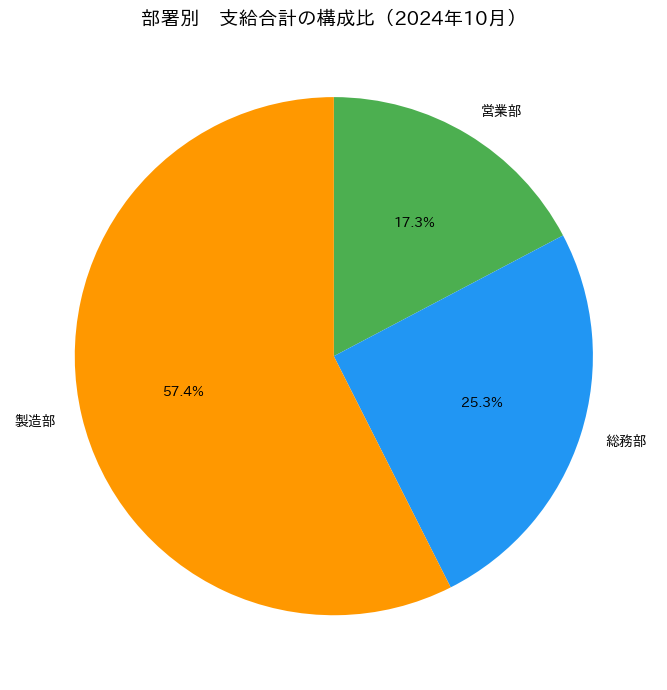

In [5]:
# 円グラフ：部署別支給合計の構成比
plt.figure(figsize=(7, 7))

plt.pie(
    df_dept["支給合計"],
    labels=df_dept["部署"],
    autopct="%1.1f%%",          # パーセント表示
    colors=["#4CAF50", "#2196F3", "#FF9800"],
    startangle=90,              # 12時の位置から開始
    counterclock=False          # 時計回り
)

plt.title("部署別　支給合計の構成比（2024年10月）", fontsize=14)
plt.tight_layout()
plt.show()

# pythonautopct="%1.1f%%"   # 小数第1位までのパーセント表示
# startangle=90       # 12時の位置から開始（見やすい）
# counterclock=False  # 時計回りに並べる

In [6]:
from datetime import datetime

now = datetime.now().strftime("%Y%m%d_%H%M%S")

# 棒グラフを保存
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(df_dept["部署"], df_dept["支給合計_万円"],
        color=["#4CAF50", "#2196F3", "#FF9800"])
ax1.set_title("部署別　支給合計（2024年10月）", fontsize=14)
ax1.set_xlabel("部署", fontsize=12)
ax1.set_ylabel("支給合計（万円）", fontsize=12)
for i, row in df_dept.iterrows():
    ax1.text(i, row["支給合計_万円"] + 1,
             f"{row['支給合計_万円']:,.1f}万円",
             ha="center", fontsize=10)
fig1.tight_layout()
fig1.savefig(f"/content/drive/MyDrive/Colab Notebooks/棒グラフ_{now}.png",
             dpi=150, bbox_inches="tight")
plt.close(fig1)

# 円グラフを保存
fig2, ax2 = plt.subplots(figsize=(7, 7))
ax2.pie(df_dept["支給合計"],
        labels=df_dept["部署"],
        autopct="%1.1f%%",
        colors=["#4CAF50", "#2196F3", "#FF9800"],
        startangle=90,
        counterclock=False)
ax2.set_title("部署別　支給合計の構成比（2024年10月）", fontsize=14)
fig2.tight_layout()
fig2.savefig(f"/content/drive/MyDrive/Colab Notebooks/円グラフ_{now}.png",
             dpi=150, bbox_inches="tight")
plt.close(fig2)

print("✅ グラフを保存しました")
print(f"　棒グラフ_{now}.png")
print(f"　円グラフ_{now}.png")

✅ グラフを保存しました
　棒グラフ_20260406_041952.png
　円グラフ_20260406_041952.png
